# OpenAlex Topics Analysis

This notebook analyzes the distribution of topics per author from the OpenAlex dataset stored in Azure Cosmos DB.

## Import Required Libraries

In [1]:
import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Connect to Cosmos DB

Set up your connection string and database/container names.

In [3]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"  # Update with your database name
CONTAINER_NAME = "openalex-works"  # Update with your container name

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINER_NAME}")

Connected to database: aegisraw, container: openalex-works


## Query and Load Data

Query documents from Cosmos DB. We'll fetch documents with topics and authorships information.

In [14]:
# Query documents with topics and authors
# Adjust the query based on your needs (you may want to limit results for initial exploration)
query = """
SELECT c.id, c.title, c.authorships, c.topics, c.primary_topic
FROM c
WHERE IS_DEFINED(c.topics) AND ARRAY_LENGTH(c.topics) > 0
AND IS_DEFINED(c.authorships) AND ARRAY_LENGTH(c.authorships) > 0
"""

# Fetch documents (limit to first batch for exploration)
items = list(container.query_items(
    query=query,
    enable_cross_partition_query=True,
    max_item_count=1000  # Adjust this based on your needs
))

print(f"Fetched {len(items)} documents")

Fetched 132071 documents


## Extract and Prepare Data

Extract author and topic information from the documents.

In [7]:
# Extract author-topic relationships
author_topics = defaultdict(list)  # {author_id: [list of topics]}
author_names = {}  # {author_id: author_name}
author_paper_counts = defaultdict(int)  # {author_id: number of papers}

for item in items:
    # Extract topics for this paper
    paper_topics = []
    if item.get('topics'):
        for topic in item['topics']:
            if topic.get('id'):
                paper_topics.append({
                    'id': topic['id'],
                    'display_name': topic.get('display_name', 'Unknown'),
                    'score': topic.get('score', 0)
                })
    
    # Extract authors and link to topics
    if item.get('authorships'):
        for authorship in item['authorships']:
            author = authorship.get('author', {})
            author_id = author.get('id')
            author_name = author.get('display_name', 'Unknown')
            
            if author_id:
                # Store author name
                author_names[author_id] = author_name
                
                # Count papers
                author_paper_counts[author_id] += 1
                
                # Associate topics with this author
                for topic in paper_topics:
                    author_topics[author_id].append(topic)

print(f"Processed {len(author_names)} unique authors")
print(f"Total author-topic associations: {sum(len(topics) for topics in author_topics.values())}")

Processed 180256 unique authors
Total author-topic associations: 448480


## Analyze Topics Per Author

Calculate statistics on the number of topics per author.

In [8]:
# Calculate unique topics per author
author_unique_topics = {}
author_topic_diversity = {}

for author_id, topics in author_topics.items():
    # Get unique topics
    unique_topic_ids = set(topic['id'] for topic in topics)
    author_unique_topics[author_id] = len(unique_topic_ids)
    
    # Calculate topic diversity (number of unique topics / total papers)
    author_topic_diversity[author_id] = len(unique_topic_ids) / author_paper_counts[author_id]

# Create a DataFrame for analysis
author_stats_df = pd.DataFrame({
    'author_id': list(author_names.keys()),
    'author_name': [author_names[aid] for aid in author_names.keys()],
    'num_papers': [author_paper_counts[aid] for aid in author_names.keys()],
    'total_topics': [len(author_topics[aid]) for aid in author_names.keys()],
    'unique_topics': [author_unique_topics[aid] for aid in author_names.keys()],
    'topic_diversity': [author_topic_diversity[aid] for aid in author_names.keys()]
})

# Sort by number of papers
author_stats_df = author_stats_df.sort_values('num_papers', ascending=False)

print("\nAuthor Statistics Summary:")
print(author_stats_df[['num_papers', 'unique_topics', 'topic_diversity']].describe())
print("\nTop 10 authors by number of papers:")
print(author_stats_df[['author_name', 'num_papers', 'unique_topics', 'topic_diversity']].head(10))


Author Statistics Summary:
          num_papers  unique_topics  topic_diversity
count  180256.000000  180256.000000    180256.000000
mean        1.108684       2.427253         2.228492
std         0.574927       1.246270         0.862701
min         1.000000       1.000000         0.333333
25%         1.000000       1.000000         1.000000
50%         1.000000       3.000000         3.000000
75%         1.000000       3.000000         3.000000
max        41.000000      45.000000         3.000000

Top 10 authors by number of papers:
                          author_name  num_papers  unique_topics  \
24333                    Nelios media          41             36   
2432                     José Antonio          30             41   
20411  Fernando López Lerdo de Tejada          28             20   
20491                    Stijn Vogels          28             39   
21546                      Quim Casas          27             41   
34907                 Enrico Reggiani          27 

## Visualize Topic Distribution

Create visualizations to understand topic distribution patterns.

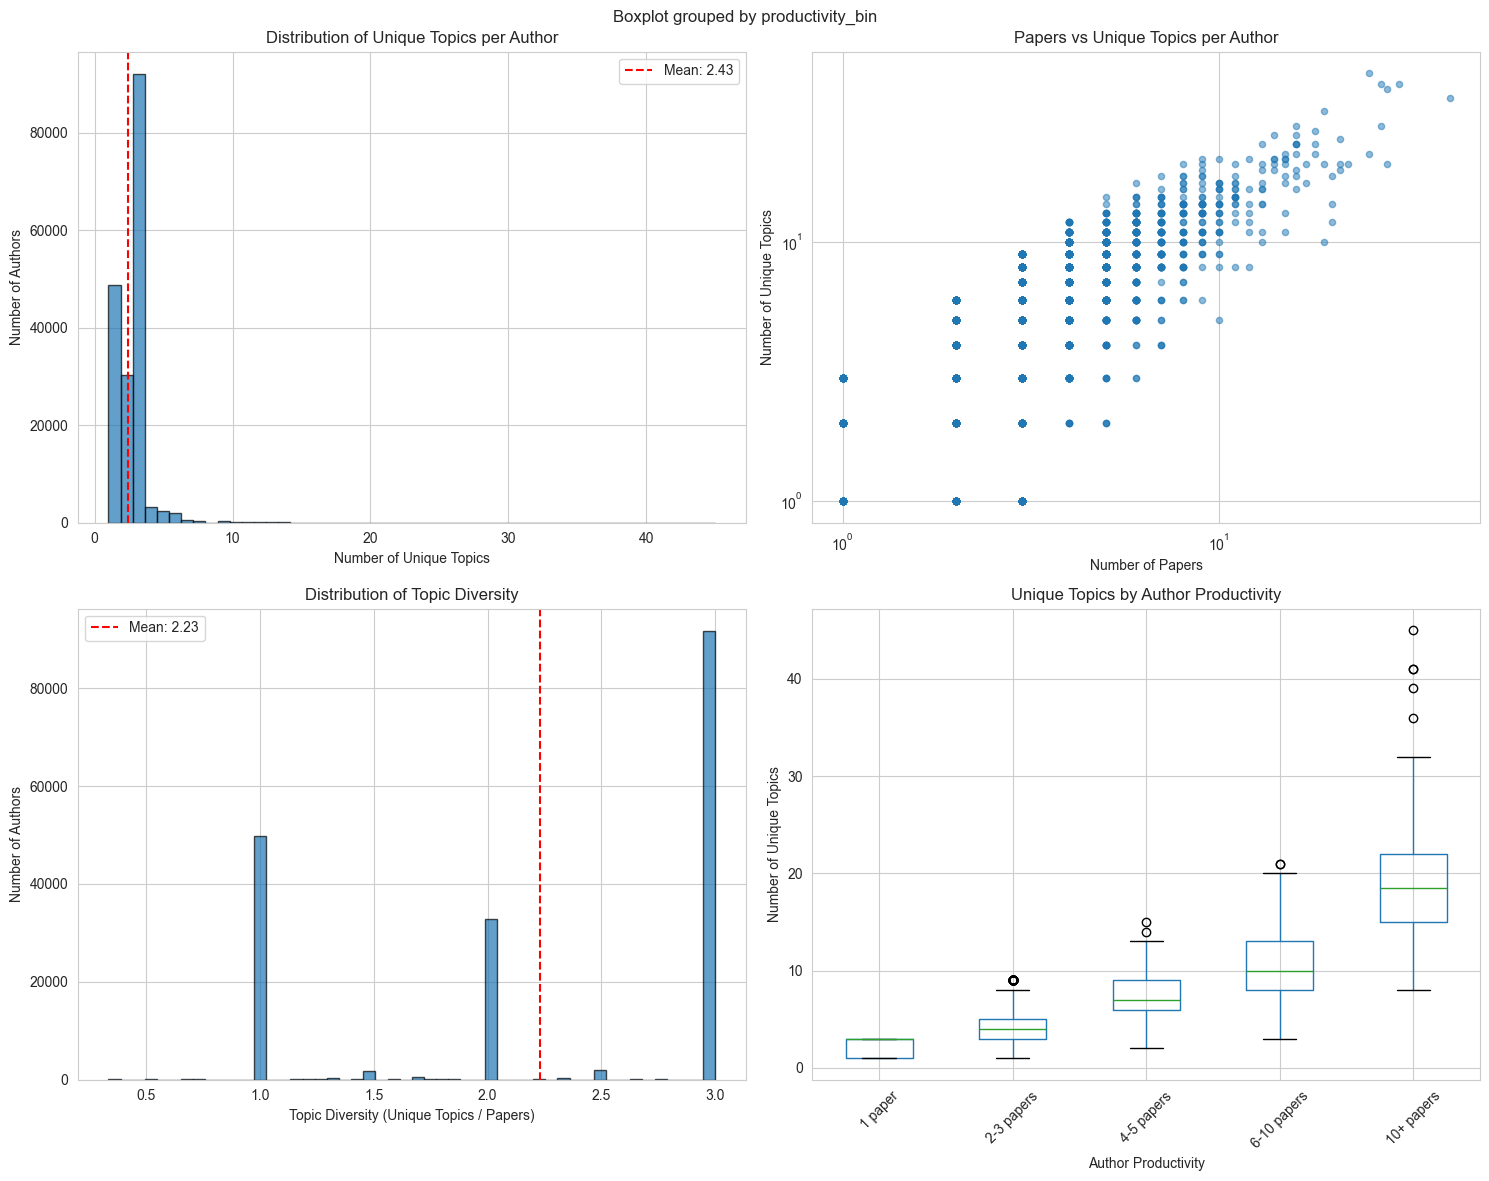

In [9]:
# Distribution of unique topics per author
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram of unique topics per author
axes[0, 0].hist(author_stats_df['unique_topics'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Unique Topics')
axes[0, 0].set_ylabel('Number of Authors')
axes[0, 0].set_title('Distribution of Unique Topics per Author')
axes[0, 0].axvline(author_stats_df['unique_topics'].mean(), color='red', 
                    linestyle='--', label=f"Mean: {author_stats_df['unique_topics'].mean():.2f}")
axes[0, 0].legend()

# 2. Scatter plot: Papers vs Unique Topics
axes[0, 1].scatter(author_stats_df['num_papers'], author_stats_df['unique_topics'], 
                   alpha=0.5, s=20)
axes[0, 1].set_xlabel('Number of Papers')
axes[0, 1].set_ylabel('Number of Unique Topics')
axes[0, 1].set_title('Papers vs Unique Topics per Author')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

# 3. Topic diversity distribution
axes[1, 0].hist(author_stats_df['topic_diversity'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Topic Diversity (Unique Topics / Papers)')
axes[1, 0].set_ylabel('Number of Authors')
axes[1, 0].set_title('Distribution of Topic Diversity')
axes[1, 0].axvline(author_stats_df['topic_diversity'].mean(), color='red', 
                    linestyle='--', label=f"Mean: {author_stats_df['topic_diversity'].mean():.2f}")
axes[1, 0].legend()

# 4. Box plot of topics by author productivity bins
author_stats_df['productivity_bin'] = pd.cut(author_stats_df['num_papers'], 
                                               bins=[0, 1, 3, 5, 10, float('inf')],
                                               labels=['1 paper', '2-3 papers', '4-5 papers', 
                                                      '6-10 papers', '10+ papers'])
author_stats_df.boxplot(column='unique_topics', by='productivity_bin', ax=axes[1, 1])
axes[1, 1].set_xlabel('Author Productivity')
axes[1, 1].set_ylabel('Number of Unique Topics')
axes[1, 1].set_title('Unique Topics by Author Productivity')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Most Common Topics

Identify the most common topics across all authors.

Top 20 Most Common Topics:
                                           topic_name  count
0               Archaeological and Historical Studies   4855
1                        Social Sciences and Policies   4044
2                   Finance, Taxation, and Governance   2849
3                        Health, Medicine and Society   2758
4               Medieval Architecture and Archaeology   2745
5   Historical and socio-economic studies of Spain...   2675
6             Historical Art and Architecture Studies   2585
7                Aging, Elder Care, and Social Issues   2580
8              Spanish Literature and Culture Studies   2455
9                 Hermeneutics and Narrative Identity   2404
10            Comparative International Legal Studies   2298
11                       Human Rights and Immigration   2257
12              Employment, Labor, and Gender Studies   2007
13              Historical Studies of Medieval Iberia   1987
14        Comparative Literary Analysis and Criticism   19

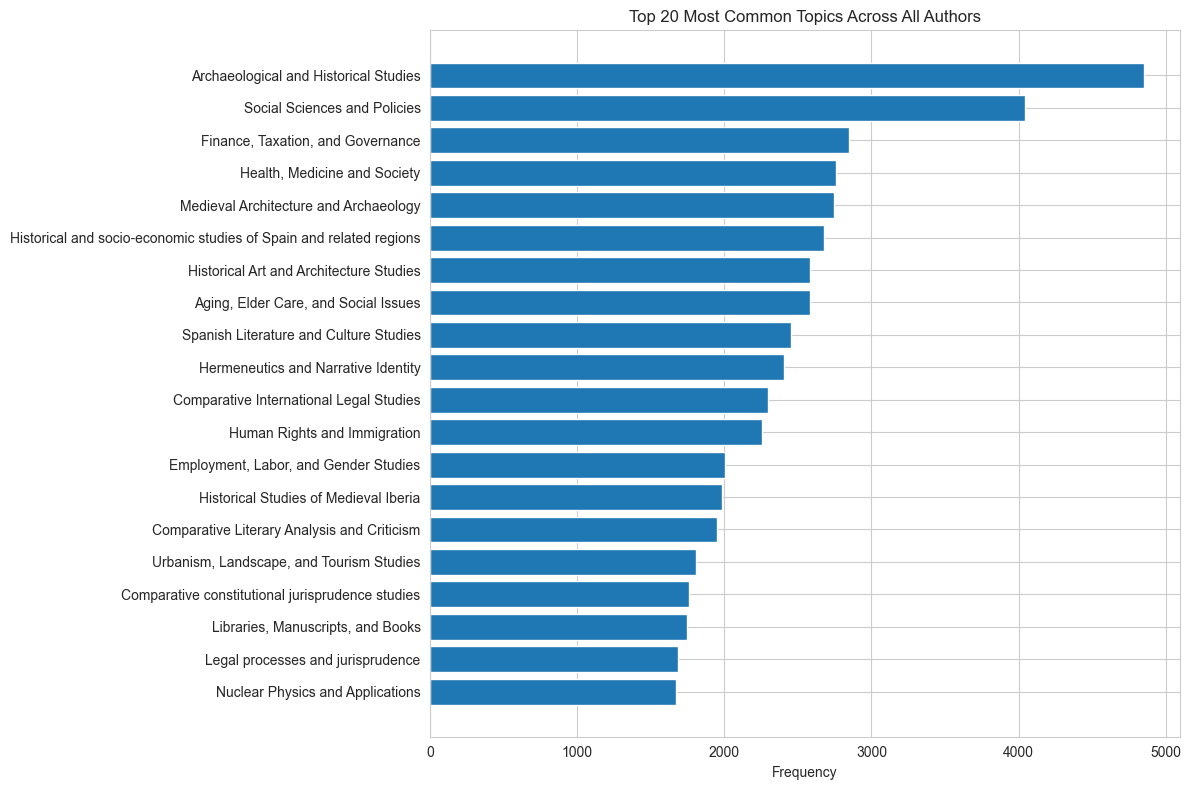

In [10]:
# Count all topics
all_topics = []
for topics in author_topics.values():
    for topic in topics:
        all_topics.append((topic['id'], topic['display_name']))

topic_counter = Counter(all_topics)
top_topics = topic_counter.most_common(20)

# Create DataFrame for top topics
top_topics_df = pd.DataFrame(top_topics, columns=['topic', 'count'])
top_topics_df['topic_name'] = top_topics_df['topic'].apply(lambda x: x[1])
top_topics_df['topic_id'] = top_topics_df['topic'].apply(lambda x: x[0])

print("Top 20 Most Common Topics:")
print(top_topics_df[['topic_name', 'count']])

# Visualize top topics
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_topics_df)), top_topics_df['count'])
plt.yticks(range(len(top_topics_df)), top_topics_df['topic_name'])
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Topics Across All Authors')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Author Topic Specialization

Analyze how specialized authors are in their topics.

In [15]:
# Calculate total unique topics across all papers
unique_topics_count = len(topic_counter)
print(f"\n{'='*60}")
print(f"Total Unique Topics Across All Papers: {unique_topics_count:,}")
print(f"{'='*60}")
print(f"\nTotal papers analyzed: {len(items):,}")
print(f"Total topic occurrences: {sum(topic_counter.values()):,}")
print(f"Average topics per paper: {sum(topic_counter.values()) / len(items):.2f}")


Total Unique Topics Across All Papers: 4,453

Total papers analyzed: 132,071
Total topic occurrences: 448,480
Average topics per paper: 3.40



Topic Concentration Statistics:
count    180256.000000
mean          0.534891
std           0.291486
min           0.024221
25%           0.333333
50%           0.333333
75%           1.000000
max           1.000000
Name: topic_concentration, dtype: float64

Most Specialized Authors (with 3+ papers):
            author_name  num_papers  unique_topics  topic_concentration
21474   Fernando García           3              1                  1.0
6779   Bruce A. Bassett           3              1                  1.0
6780          A. Becker           3              1                  1.0
6782      H. Brewington           3              1                  1.0
6783    Chang‐Hoon Choi           3              1                  1.0
6785        C. D’Andrea           3              1                  1.0
6786        J. Dembicky           3              1                  1.0
6787        D. L. DePoy           3              1                  1.0
6788          B. Dilday           3              

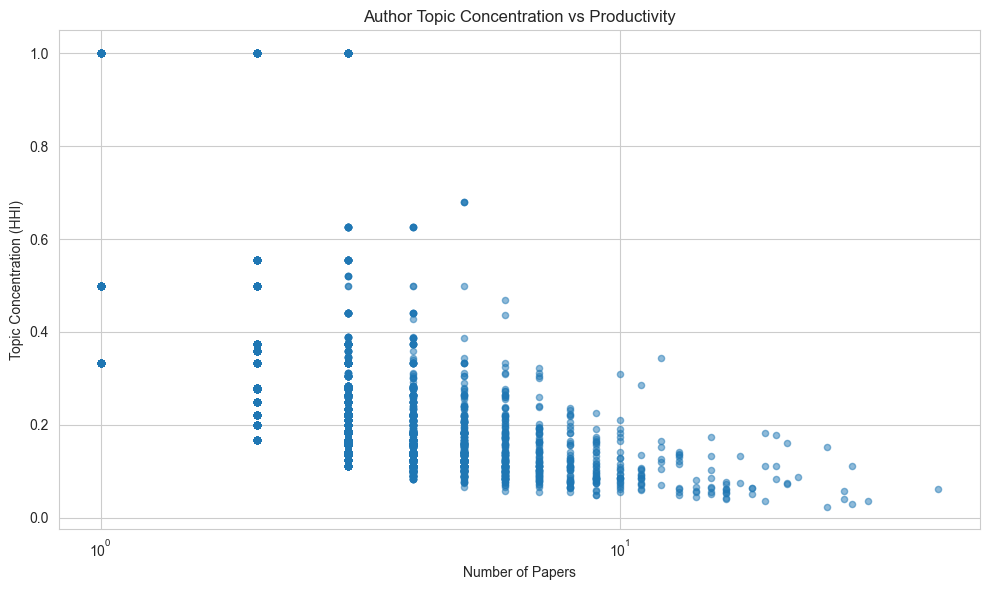

In [11]:
# Calculate topic concentration for each author
# Using Herfindahl-Hirschman Index (HHI) - higher values = more concentrated/specialized

def calculate_hhi(topics_list):
    """Calculate HHI for topic distribution"""
    if not topics_list:
        return 0
    
    # Count topic occurrences
    topic_counts = Counter(topic['id'] for topic in topics_list)
    total = len(topics_list)
    
    # Calculate HHI
    hhi = sum((count / total) ** 2 for count in topic_counts.values())
    return hhi

author_stats_df['topic_concentration'] = author_stats_df['author_id'].apply(
    lambda aid: calculate_hhi(author_topics[aid])
)

# Authors with single-topic focus have HHI = 1, diverse authors have lower HHI
print("\nTopic Concentration Statistics:")
print(author_stats_df['topic_concentration'].describe())

# Find most specialized authors (high HHI, multiple papers)
specialized_authors = author_stats_df[author_stats_df['num_papers'] >= 3].nlargest(10, 'topic_concentration')
print("\nMost Specialized Authors (with 3+ papers):")
print(specialized_authors[['author_name', 'num_papers', 'unique_topics', 'topic_concentration']])

# Find most diverse authors (low HHI, multiple papers)
diverse_authors = author_stats_df[author_stats_df['num_papers'] >= 3].nsmallest(10, 'topic_concentration')
print("\nMost Diverse Authors (with 3+ papers):")
print(diverse_authors[['author_name', 'num_papers', 'unique_topics', 'topic_concentration']])

# Visualize concentration vs diversity
plt.figure(figsize=(10, 6))
plt.scatter(author_stats_df['num_papers'], author_stats_df['topic_concentration'], 
            alpha=0.5, s=20)
plt.xlabel('Number of Papers')
plt.ylabel('Topic Concentration (HHI)')
plt.title('Author Topic Concentration vs Productivity')
plt.xscale('log')
plt.tight_layout()
plt.show()